## 4.4 拉丁超立方设计

我们需要处理的影响因素或许有成百上千个，但真正对输出结果起到关键作用的因素可能仅有少数几个。著名的帕累托原理指出，系统中 20% 的影响因素，便能解释输出结果 80% 的变异情况。在试验设计相关文献中，该规律被称作效应稀疏原理（吴与滨田，2021，第 169 页）。这种普遍存在的现象会对试验设计产生怎样的影响？

考虑一个包含两个因子、4 次试验的试验设计，极大极小设计与极小极大设计如图 4.6 所示。本例中基于聚类的设计和极小极大设计完全一致。现假设因子 $x_2$ 无关紧要，即其对输出结果的影响可以忽略不计。那么对于左侧的设计而言，相当于在 $x_1=0$ 和 $x_1=1$ 两处各开展了两次试验；对于右侧设计，则是在 $x_1=0.25$ 和 $x_1=0.75$ 两处各重复两次试验。由于输出不存在误差，试验得到的输出数值将会完全相同。这一点在开展试验前就能预判，也就是说，重复开展这两组试验纯属浪费时间。倘若 $x_1$ 无影响、仅有 $x_2$ 起作用，也会出现相同的问题。这类不理想的情形在实际应用中极易出现，我们该如何规避？

> **图 4.6** 四轮试验下的极大极小与极小极大设计，及其在各坐标轴上的投影。

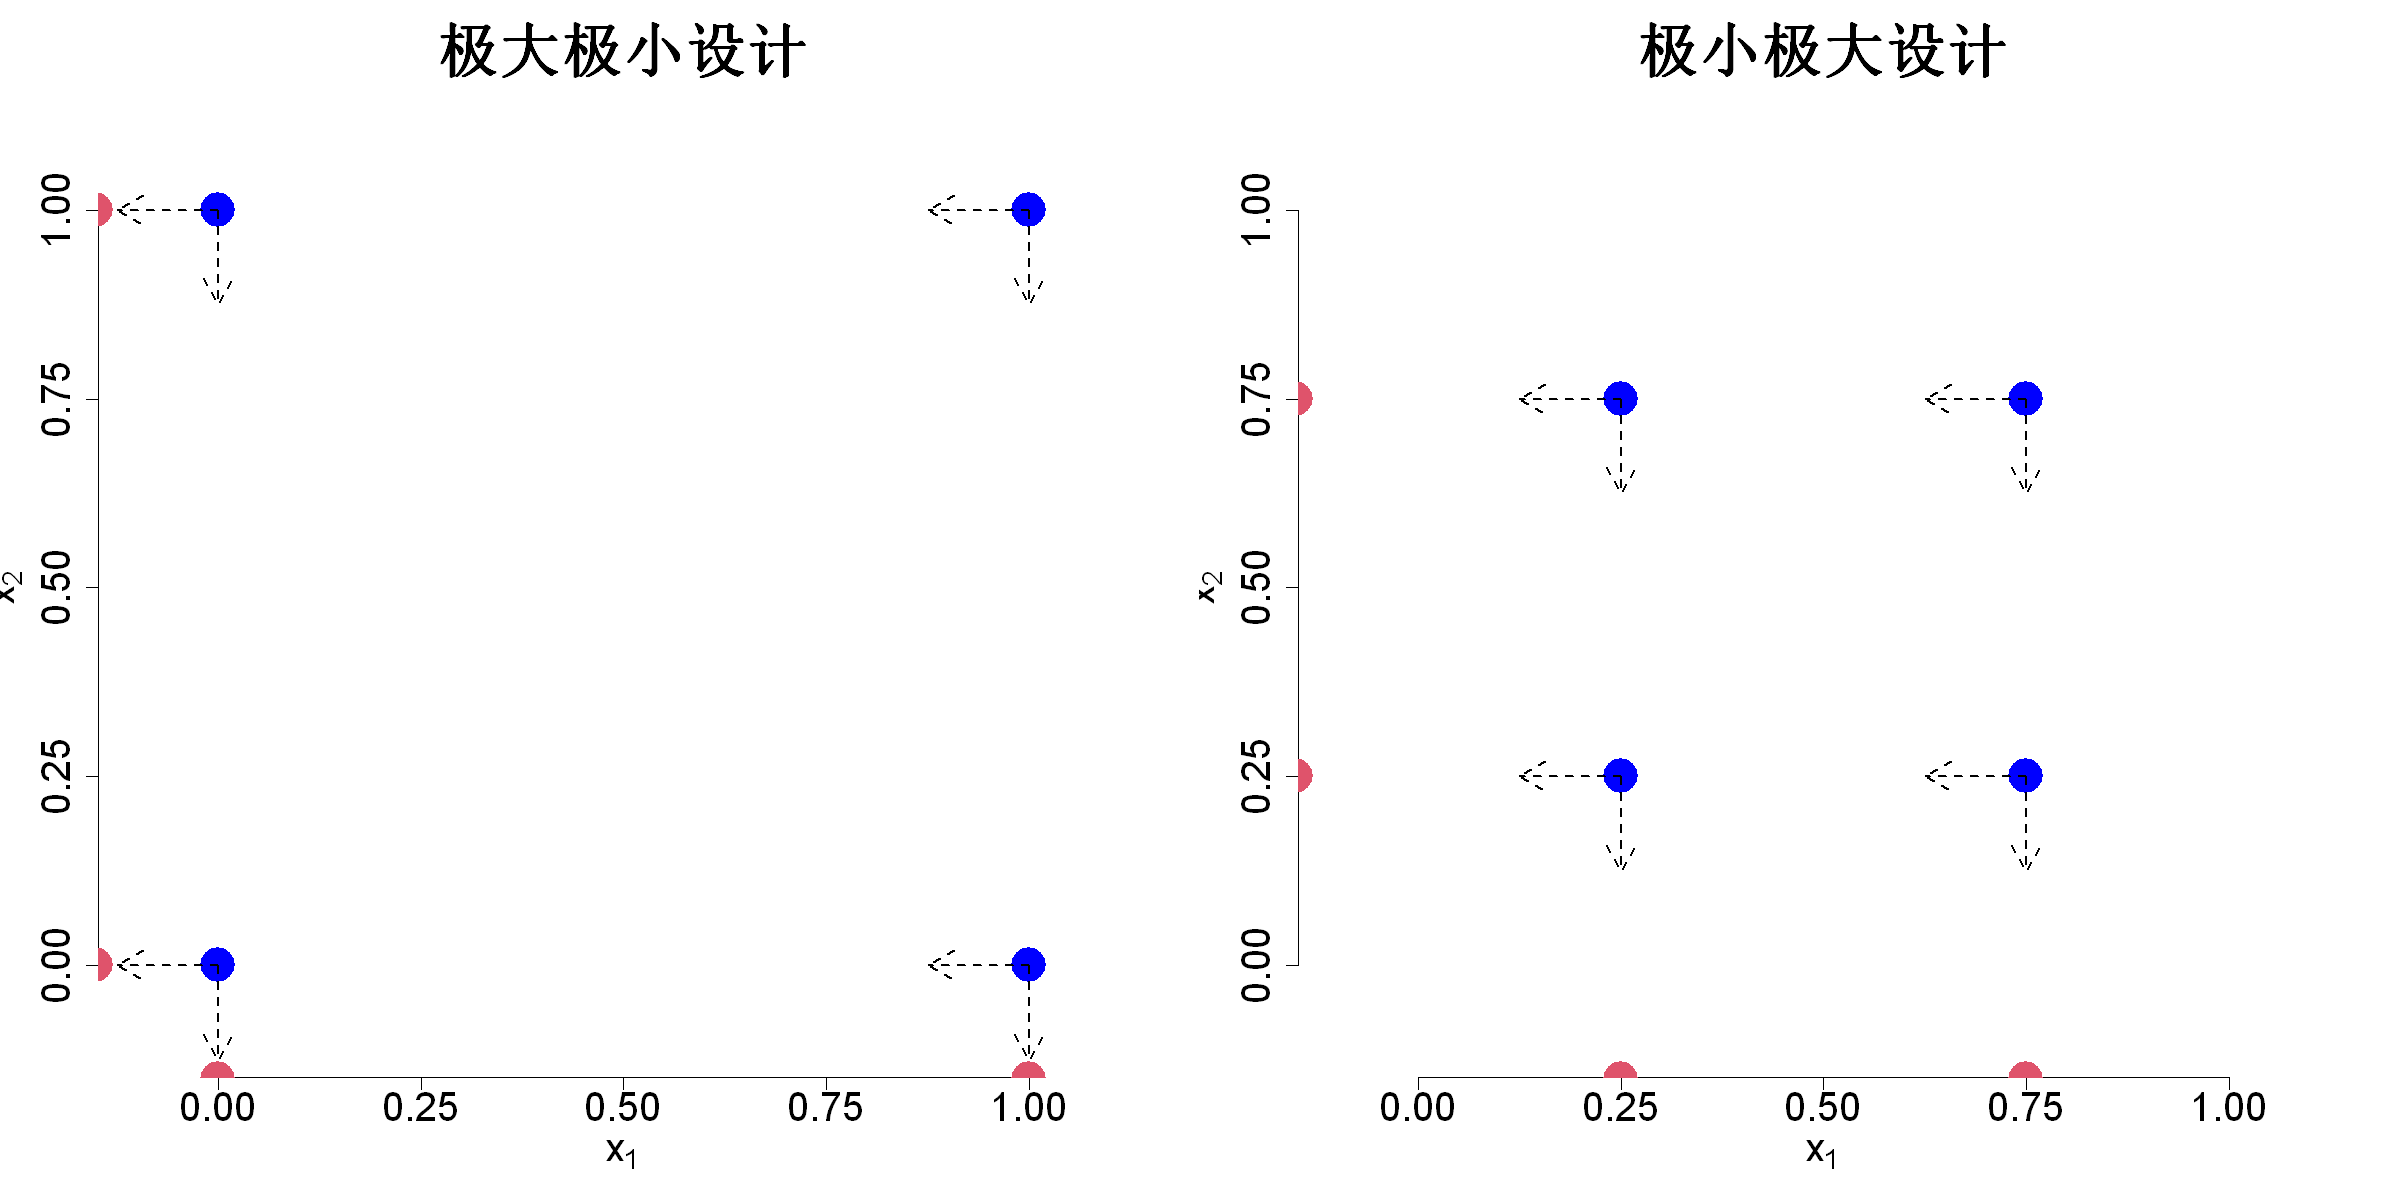

In [12]:
options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
D=matrix(c(0,0,0,1,1,0,1,1),nrow=4,ncol=2,byrow=TRUE)
plot(D,pch=16,xaxt="n",yaxt="n",cex=4,bty="n",col="blue",xlim=c(-.1,1.1),ylim=c(-.1,1.1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,main="极大极小设计",cex.main=3)
axis(1,at=seq(0,1,by=.25),cex.axis=2)
axis(2,at=seq(0,1,by=.25),cex.axis=2)
points(cbind(D[,1],-.15),col=2,pch=16,cex=4)
points(cbind(-.15,D[,2]),col=2,pch=16,cex=4)
arrows(0,0,0,-.125,lwd=2,lty=2)
arrows(1,0,1,-.125,lwd=2,lty=2)
arrows(0,1,0,.875,lwd=2,lty=2)
arrows(1,1,1,.875,lwd=2,lty=2)
arrows(0,0,-.125,0,lwd=2,lty=2)
arrows(0,1,-.125,1,lwd=2,lty=2)
arrows(1,0,.875,0,lwd=2,lty=2)
arrows(1,1,.875,1,lwd=2,lty=2)

D=matrix(c(0.25,0.25,.25,.75,.75,.25,.75,.75),nrow=4,ncol=2,byrow=TRUE)
plot(D,pch=16,xaxt="n",yaxt="n",cex=4,bty="n",col="blue",xlim=c(-.1,1.1),ylim=c(-.1,1.1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,main="极小极大设计",cex.main=3)
axis(1,at=seq(0,1,by=.25),cex.axis=2)
axis(2,at=seq(0,1,by=.25),cex.axis=2)
points(cbind(D[,1],-.15),col=2,pch=16,cex=4)
points(cbind(-.15,D[,2]),col=2,pch=16,cex=4)
arrows(.25,.25,.25,.125,lwd=2,lty=2)
arrows(.75,.25,.75,.125,lwd=2,lty=2)
arrows(.25,.75,.25,.625,lwd=2,lty=2)
arrows(.75,.75,.75,.625,lwd=2,lty=2)
arrows(.25,.25,.125,.25,lwd=2,lty=2)
arrows(.25,.75,.125,.75,lwd=2,lty=2)
arrows(.75,.25,.625,.25,lwd=2,lty=2)
arrows(.75,.75,.625,.75,lwd=2,lty=2)
par(mfrow=c(1,1))

倘若我们事先知晓变量 $x_2$ 无关紧要，就应当针对变量 $x_1$ 采用最优试验设计开展四次试验；反之同理。图 4.7 左侧子图展示了这类设计方案，此处针对每个输入变量采用极小极大设计：$\{(i - 0.5)/4\}_{i=1}^4$。可以发现，将四个试验设计点分别投影至两条坐标轴上时，两个因子各自都会得到四个互不相同的数值。因此，即便试验结束后发现其中某一个因子并无显著影响，该设计方案依旧能够拥有良好的试验效果。

> **图 4.7** 4 次采样的拉丁超立方设计，其投影分别展示在各坐标轴上。

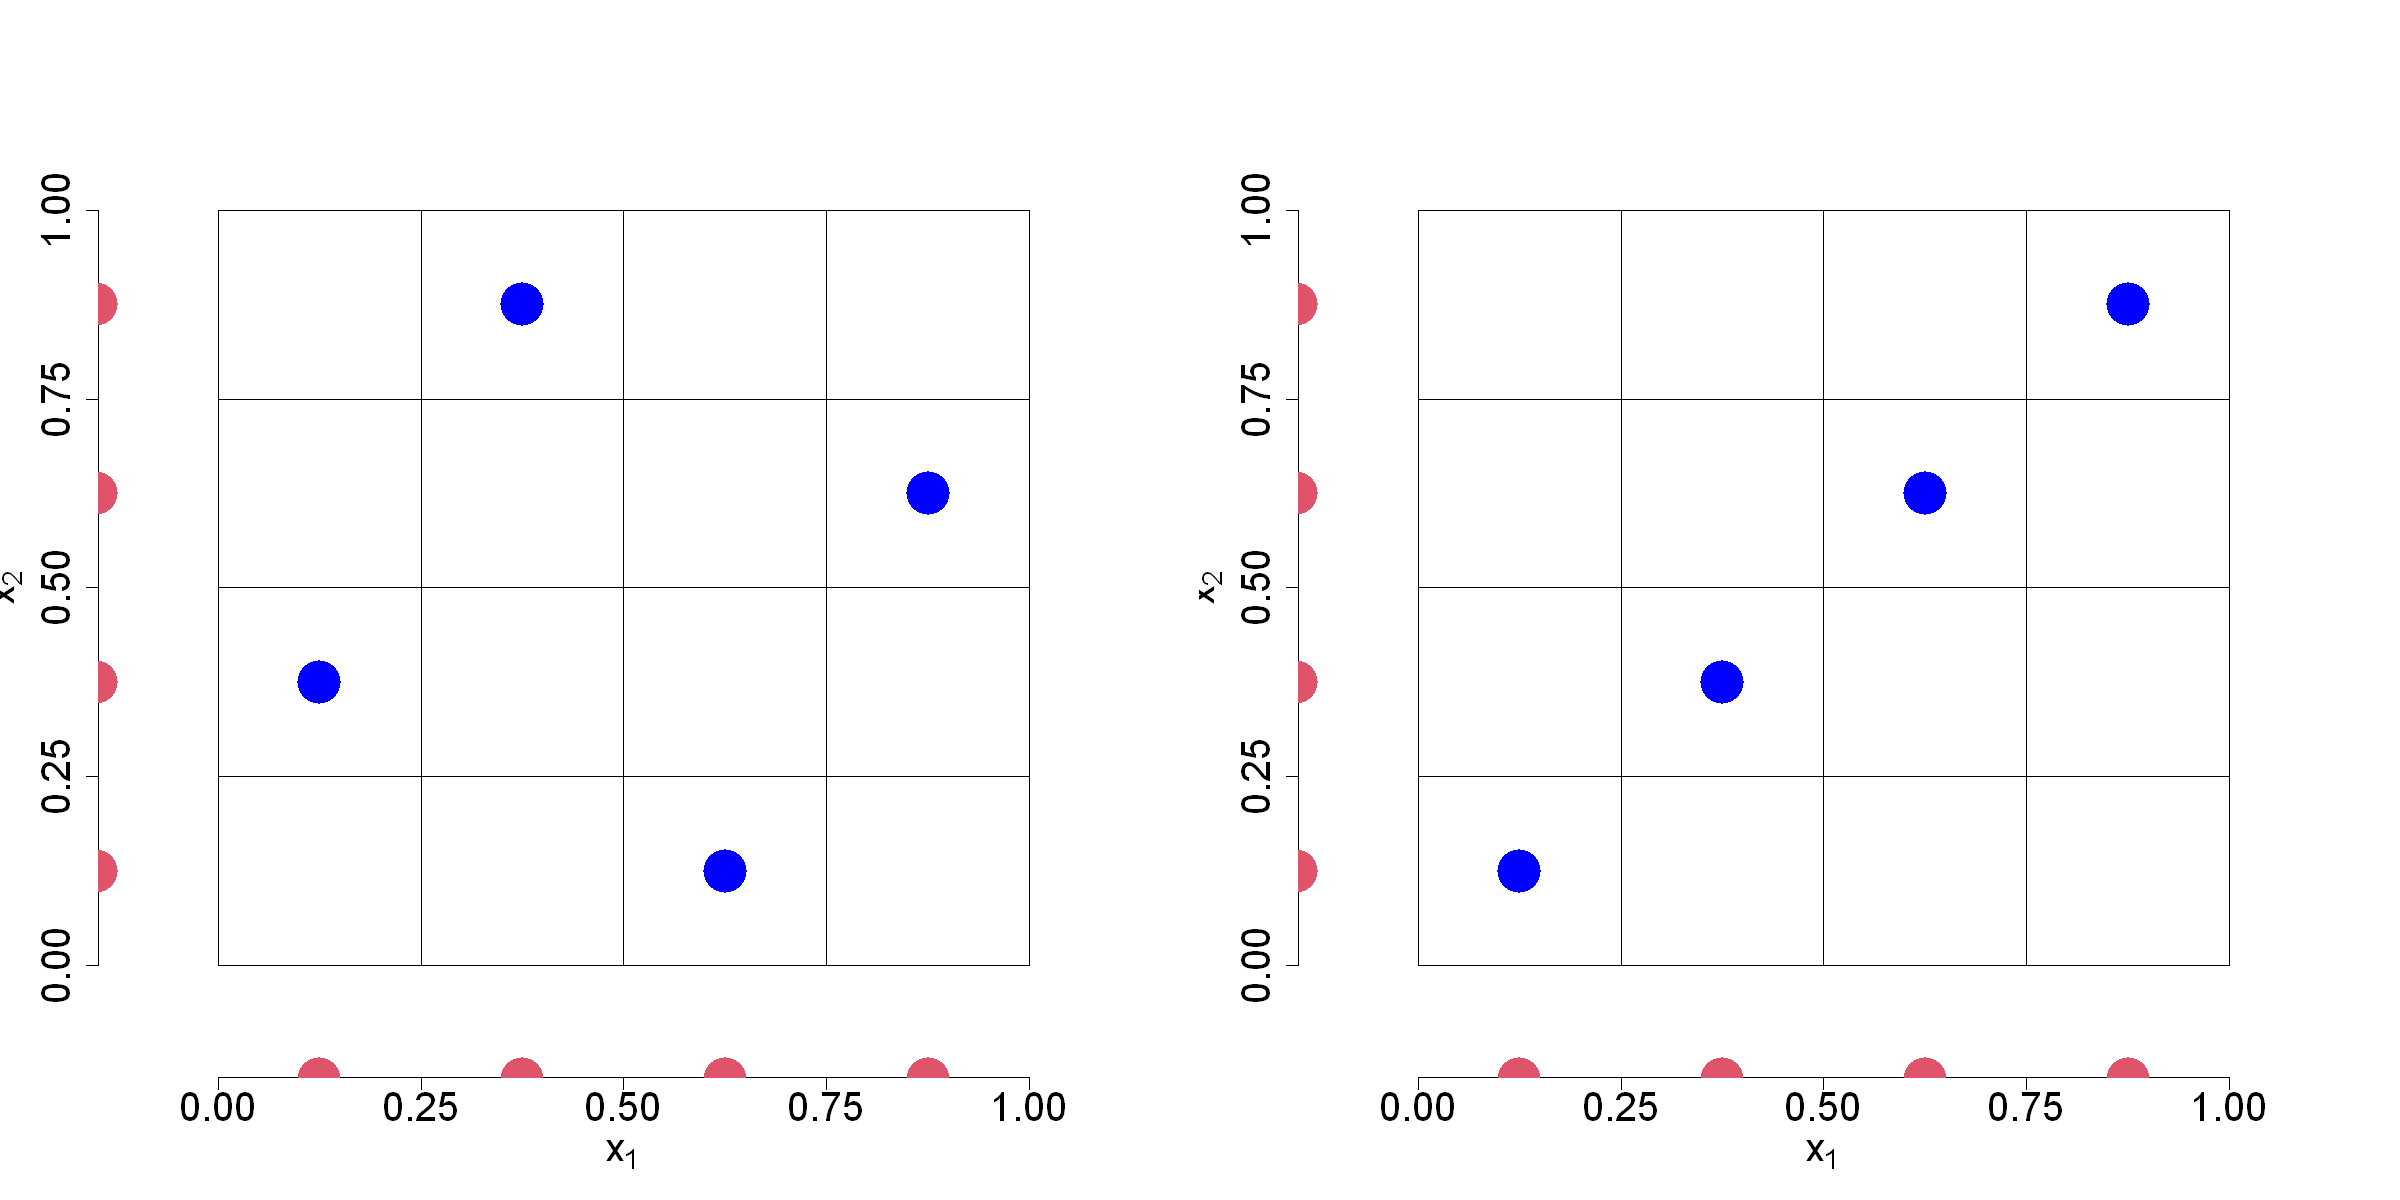

In [13]:
options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
p=2;n=4
set.seed(1)
library(SFDesign)
D=maximinLHD(n,p)$design
plot(D,pch=16,xaxt="n",yaxt="n",cex=5,bty="n",col="blue",xlim=c(-.1,1.1),ylim=c(-.1,1.1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2)
axis(1,at=seq(0,1,by=.25),cex.axis=2)
axis(2,at=seq(0,1,by=.25),cex.axis=2)
for(i in 1:(n+1))
{
segments((i-1)/n,0,(i-1)/n,1)
segments(0,(i-1)/n,1,(i-1)/n)
}
points(cbind(D[,1],-.15),col=2,pch=16,cex=5)
points(cbind(-.15,D[,2]),col=2,pch=16,cex=5)

D=(cbind(1:n,1:n)-.5)/n
plot(D,pch=16,xaxt="n",yaxt="n",cex=5,bty="n",col="blue",xlim=c(-.1,1.1),ylim=c(-.1,1.1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2)
axis(1,at=seq(0,1,by=.25),cex.axis=2)
axis(2,at=seq(0,1,by=.25),cex.axis=2)
for(i in 1:(n+1))
{
segments((i-1)/n,0,(i-1)/n,1)
segments(0,(i-1)/n,1,(i-1)/n)
}
points(cbind(D[,1],-.15),col=2,pch=16,cex=5)
points(cbind(-.15,D[,2]),col=2,pch=16,cex=5)
par(mfrow=c(1,1))

构造具备优良一维投影特性的试验设计十分简便。将每一条坐标轴均划分为 $n$ 个等间距区间。随后，只需保证每行、每列仅存在一个样本点，即可得到所需投影效果，具体形式见图 4.7。拓展至高维情形时，可通过下式实现：

$$
\left\{\frac{\pi_j(i)-0.5}{n}\right\}_{i=1}^n
\tag{4.21}
$$

上式对应设计的第 $j$ 列，其中 $\{\pi_j(1),\dots,\pi_j(n)\}$ 是整数集合 $\{1,\dots,n\}$ 的一组随机排列。这类设计被称作拉丁超立方设计（LHD）（麦凯等人，1979年）。也可在每个单元格内部对样本点做随机扰动，扰动形式写作 $\{(\pi_j(i)-u_{ij})/n\}_{i=1}^n$，式中 $u_{ij}$ 相互独立且均服从区间 $(0,1)$ 上的均匀分布，$i=1,\dots,n$，$j=1,\dots,p$。从试验设计的角度来看，无需引入随机扰动，因此本文采用单元格中心点构造设计，也就是式 (4.21) 中令 $u_{ij}=0.5$ 的形式。

尽管拉丁超立方抽样（LHD）能够实现优质的一维投影，但构造该抽样时所采用的随机置换未必总能具备优良特性。图 4.7 右侧子图展示了一例随机拉丁超立方抽样样本。不难看出该拉丁超立方抽样方案效果较差，原因是两个因子完全相关，并且在试验区域内留下了大片空白区间。唐（1993）将拉丁超立方思想与正交阵列（OA）相结合，构造出性能更优的拉丁超立方抽样。例如，采用强度为 2 的正交阵列，能够让样本点在二维投影空间中分布得更加均匀。欧文（1994）尝试通过降低各列之间的相关性来改进拉丁超立方抽样方案。帕克（1994）提出参照第 3 章的思路，寻找可最小化积分均方误差（IMSE）或最大化熵的拉丁超立方抽样方案。但该方法需要预先获知相关系数，一旦系数设定有误，最优拉丁超立方抽样的稳健性就会变差。莫里斯与米切尔（1995）提出采用最大最小准则优化拉丁超立方抽样，该准则既可保证良好的空间填充特性，也能实现优质的一维投影，由此得到的设计被称为最大最小拉丁超立方抽样，简称 MmLHD。二人还特别提出采用式 (4.18) 中的 TRD 准则：

$$
\min_{D\in\mathcal{L}}\sum_{i=1}^n\sum_{j\neq i}\frac{1}{\|\boldsymbol{x}_i - \boldsymbol{x}_j\|^{2\alpha}}
$$

式中 $\mathcal{L}$ 代表全体拉丁超立方抽样构成的集合。将最大最小准则与拉丁超立方抽样结合是十分合适的组合方式，该方法简洁高效，也使得最大最小拉丁超立方抽样成为计算机试验中应用最为广泛的设计方案。图 4.7 左侧子图中的设计即为最大最小拉丁超立方抽样。

对设计进行行置换不会改变设计本身.因此,固定第一列后,一共可以生成$(n!)^{p-1}$种随机拉丁超立方设计.在数量如此庞大的候选设计中,依据极大极小准则搜寻最优拉丁超立方设计并非易事.莫里斯与米切尔(1995)采用模拟退火算法实现高效全局优化.在模拟退火流程中,每一轮迭代都会基于当前设计生成一个新设计;若新设计能够优化目标函数,则以一定概率接受该设计并继续迭代.为生成候选新设计,莫里斯与米切尔(1995)提出随机选取一列,并交换该列中的两个元素,该操作能够保证拉丁超立方结构不变.金等人(2005)通过在迭代中高效更新距离计算,进一步改进了该算法.R语言程序包`SLHD`实现了这一算法(巴,2015).R程序包`LHD`提供基于遗传算法的优化方案(王等人,2022).`SFDesign`程序包实现了模拟退火结合确定性优化的算法(王,约瑟夫,2025c).王等人(2018)提出利用数论方法构造极大极小拉丁超立方设计,这类方法运算速度快,但在样本量$n$与维度$p$的选取上,灵活性不如数值优化算法.巴斯克斯与徐(2024)给出针对$L_{1}$距离极大极小拉丁超立方设计的整数规划方法,适用于生成小规模设计.借助`SFDesign`程序包生成的$n=7$,$p=2$的极大极小拉丁超立方设计如图4.8所示.可以观察到,该设计的采样点具备良好的空间填充效果,性能与图4.4中的极大极小设计相当,同时拥有更优良的一维投影性质.

>**图4.8** 7点最大最小距离拉丁超立方设计

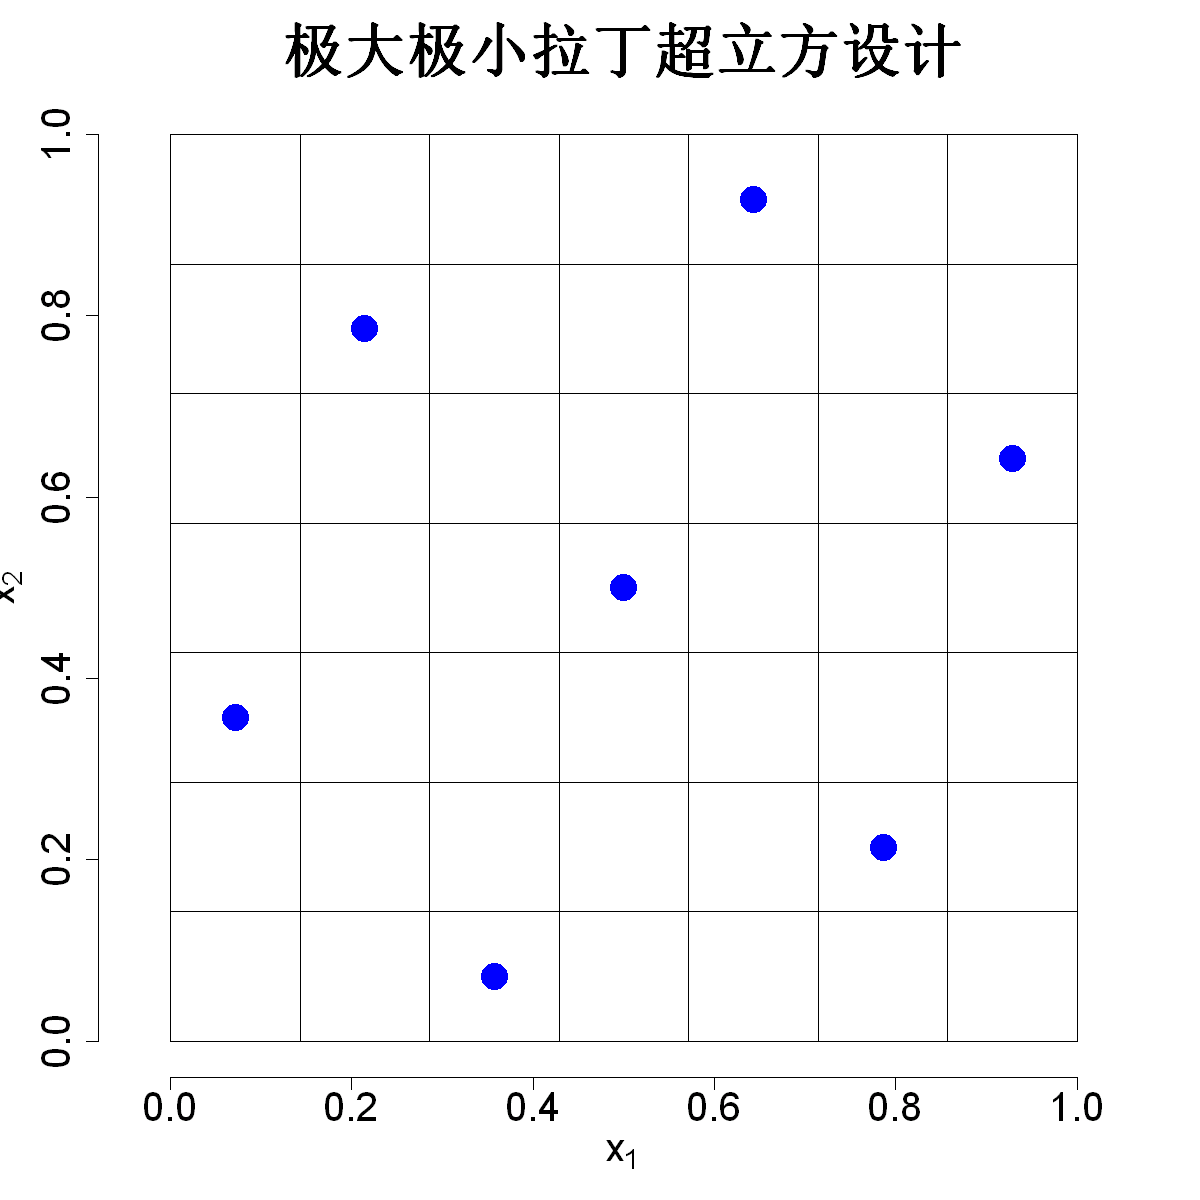

In [5]:
#图4.8

options(repr.plot.width=10,repr.plot.height=10)
p=2;n=7
set.seed(123)
library(SFDesign)
D=maximinLHD(n,p)$design
plot(D,pch=16,cex=3,bty="n",col="blue",xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,main="极大极小拉丁超立方设计",cex.main=3,asp=1)
for(i in 1:(n+1))
{
segments(0,(i-1)/n,1,(i-1)/n)
segments((i-1)/n,0,(i-1)/n,1)
}

学术界已提出多种拉丁超立方设计改进形式.叶(1998)提出正交拉丁超立方设计,该类设计所有列之间相关系数均为0.约瑟夫与亨(2008)将正交性与极大极小准则相结合,构造正交极大极小拉丁超立方设计(OMLHD).若目标为拟合均值包含线性主效应回归项的高斯过程模型,或是盲克里金模型,正交极大极小拉丁超立方设计通常表现优异(约瑟夫等人,2008).可调用R语言程序包`LHD`中的`SA2008`函数生成正交极大极小拉丁超立方设计(王等人,2022).

上述所有拉丁超立方设计均采用式(4.21)中的中心取值形式,使得一维投影构成极小极大设计.德特与佩佩利舍夫(2010)提出在一维投影上采用切比雪夫设计.若将该思路与极大极小拉丁超立方设计相结合,可先构造极大极小拉丁超立方设计,再通过式(2.5)对坐标进行变换:$D_{ij}\leftarrow(1+\cos(\pi D_{ij}))/2$,其中$D$为原始极大极小拉丁超立方设计.图4.9展示了一组20次试验的极大极小拉丁超立方设计,以及经过切比雪夫变换后的极大极小拉丁超立方设计.不难看出,切比雪夫变换会促使采样点向区域边界聚集.该方法与式(4.18)中的总倒数距离准则存在紧密联系.考虑一维情形,即$p=1$,容易推得

$$\lim_{\alpha\to0}\left\{\sum_{i=1}^{n}\sum_{j\ne i}\frac{1}{|x_{i}-x_{j}|^{2\alpha}}\right\}^{1/\alpha}=-\sum_{i=1}^{n}\sum_{j\ne i}\log|x_{i}-x_{j}|$$

等式右侧被称为对数势能.当$n\to\infty$时,最小化对数势能准则对应的设计服从反正弦分布

$$f(x)=\frac{1}{\pi\sqrt{x(1-x)}}$$

(德特与斯图登,1992).$n$点切比雪夫设计能够对该密度实现最优分位数逼近.正如前文图3.3所示,切比雪夫设计在逼近光滑函数时效果优良,但针对非光滑函数表现欠佳.由此可见,经过切比雪夫变换得到的设计,对于相关参数的设定偏差不具备稳健性.

>**图4.9** 左图为20次试验的极大极小拉丁超立方设计,右图为经过切比雪夫变换后的同一组极大极小拉丁超立方设计.

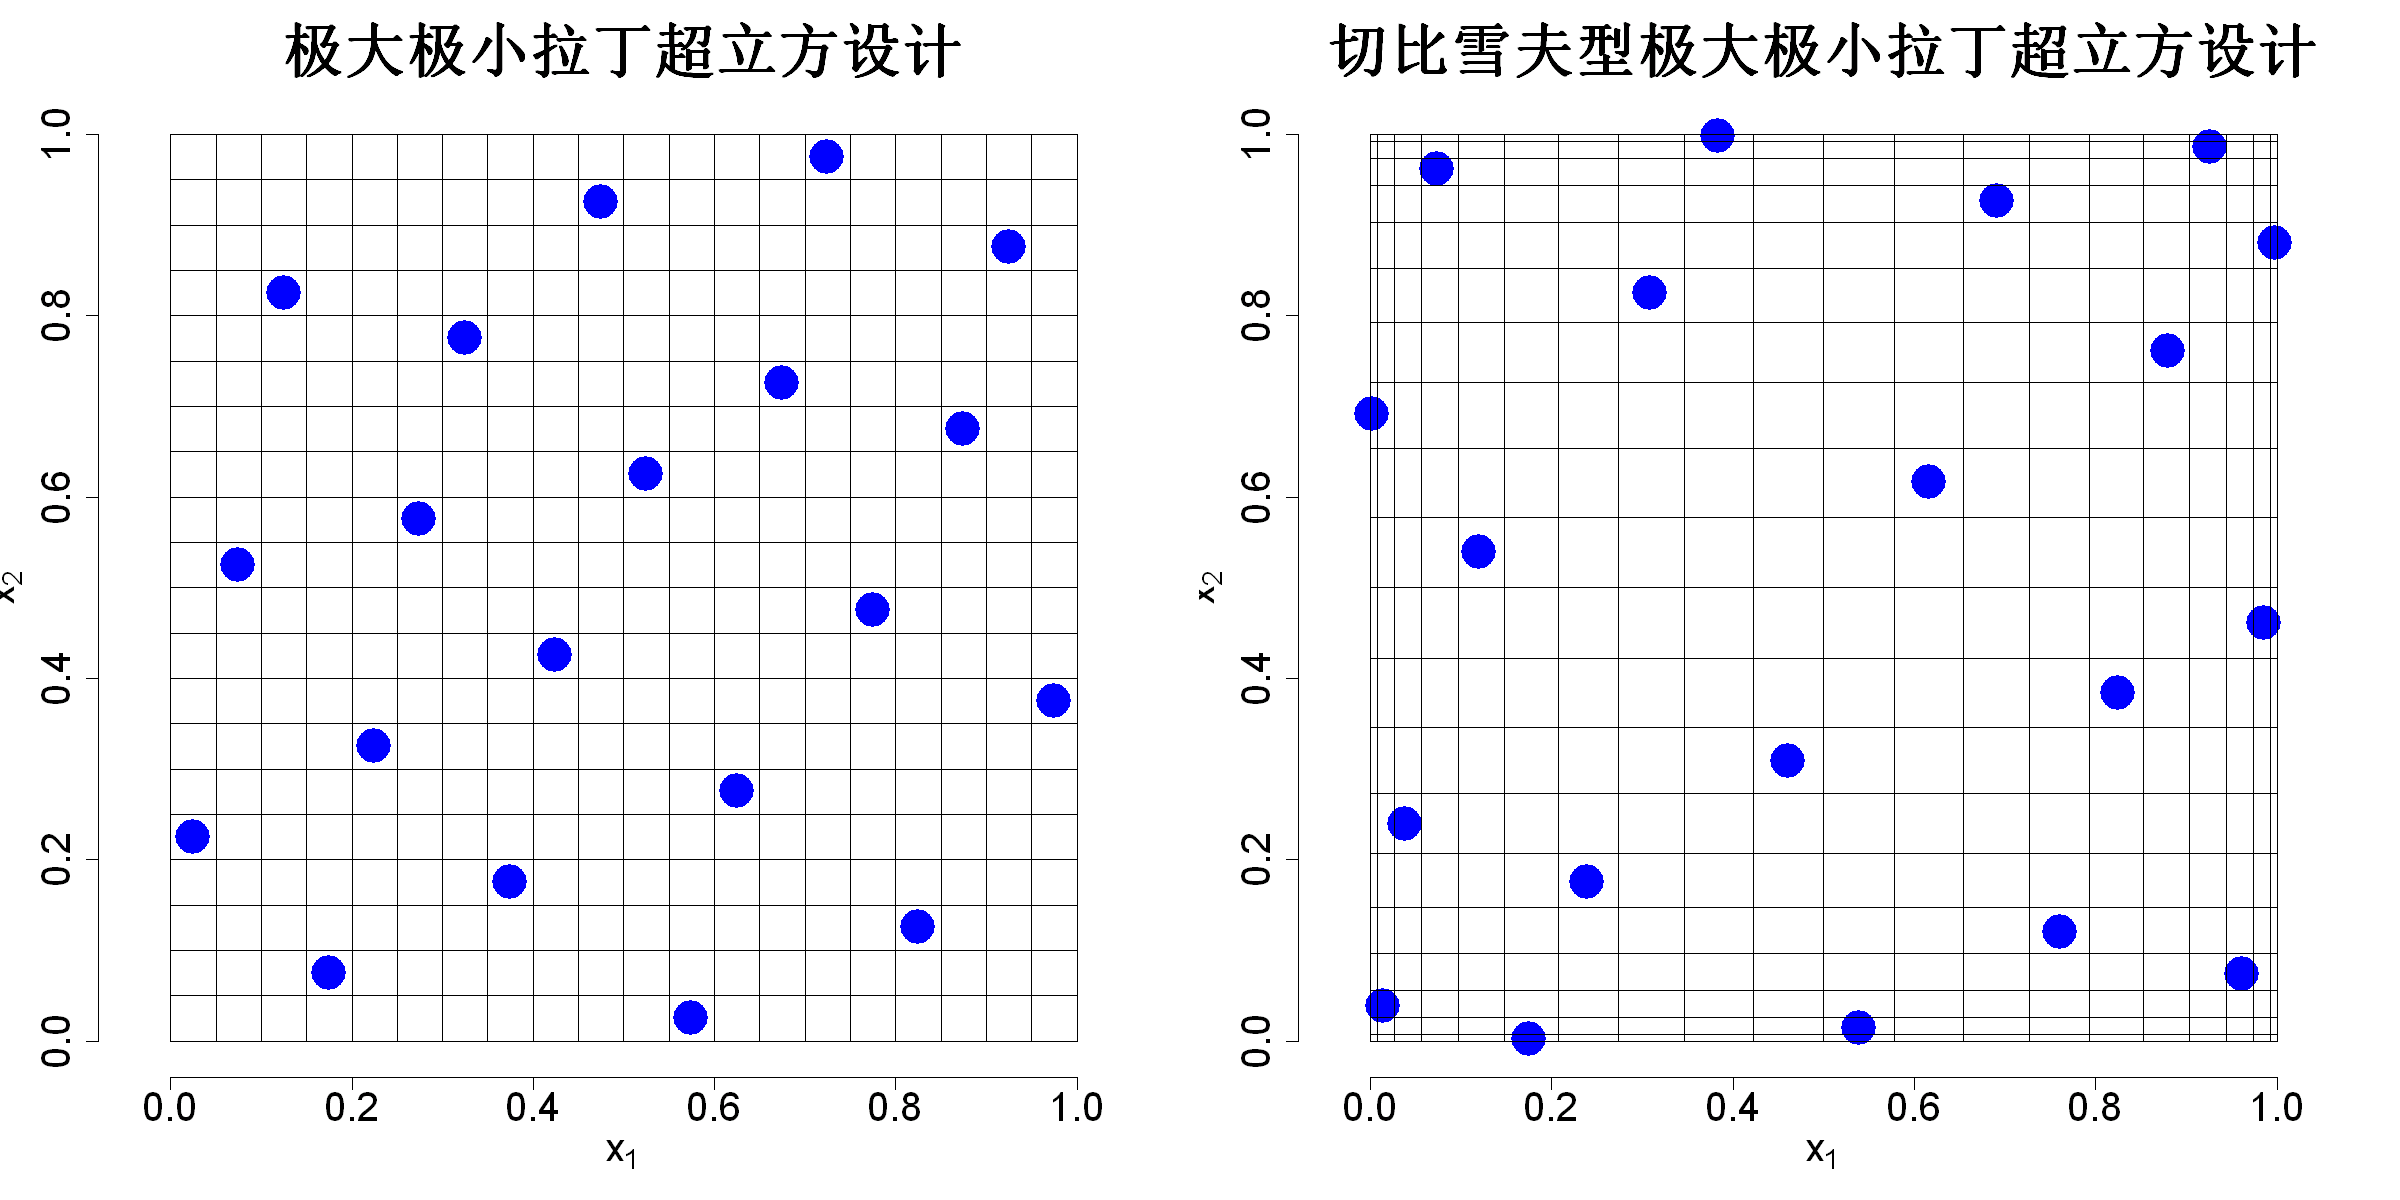

In [3]:
#图4.9

options(repr.plot.width=20,repr.plot.height=10)
par(mfrow=c(1,2))
p=2;n=20
set.seed(1)
library(SFDesign)
D=maximinLHD(n,p)$design
plot(D,pch=16,cex=4,bty="n",col="blue",xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),main="极大极小拉丁超立方设计",cex.lab=2,cex.axis=2,cex.main=3,asp=1)
for(i in 1:(n+1))
{
segments((i-1)/n,0,(i-1)/n,1)
segments(0,(i-1)/n,1,(i-1)/n)
}

D1=(1+cos(pi*D))/2
plot(D1,pch=16,cex=4,bty="n",col="blue",xlim=c(0,1),ylim=c(0,1),xlab=expression(x[1]),ylab=expression(x[2]),cex.lab=2,cex.axis=2,main="切比雪夫型极大极小拉丁超立方设计",cex.main=3,asp=1)
d1=sort(D1[,1])
l1=c(0,(d1[-1]+d1[-n])/2,1)
d2=sort(D1[,2])
l2=c(0,(d2[-1]+d2[-n])/2,1)
for(i in 1:(n+1))
{
segments(l1[i],0,l1[i],1)
segments(0,l2[i],1,l2[i])
}
par(mfrow=c(1,1))